# Lab 4 - Unsupervised learning

## M1DS - Machine Learning 1

In this lab, we are going to tackle two unsupervised learning problems : clustering and dimensionality reduction, using the `scikit-learn` library, as always.

## <div style="background-color: rgba(255, 210, 0, 0.25); padding: 8px;">
Report written by Clément Martin, my partner left the master it is why I did the lab alone.
</div>

In [1]:
# Import usual librairies
import numpy as np
from matplotlib import pyplot as plt

### Exercise 1 - Clustering

First, we are going to generate some fake data in 2D (cell below).

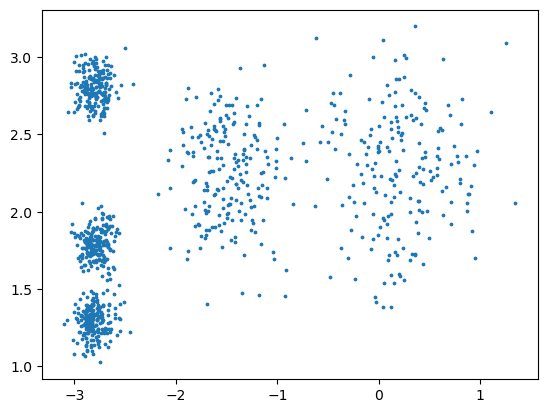

In [12]:
from sklearn.datasets import make_blobs


# Generate fake data
blob_centers = np.array([[ 0.2,  2.3], [-1.5 ,  2.3], [-2.8,  1.8],
                         [-2.8,  2.8], [-2.8,  1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, _ = make_blobs(n_samples=1000, centers=blob_centers, cluster_std=blob_std, random_state=7)

# Visualize data
plt.scatter(X[:,0], X[:,1], s=3)

**Q1.** Run the K-Means algorithm with $K = 5$ (check the documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)), and display on the same plot the clusters (i.e., each data point is colored depending on its cluster) and their centroids. Comment.

C:\Users\maner\anaconda3\envs\ml1\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


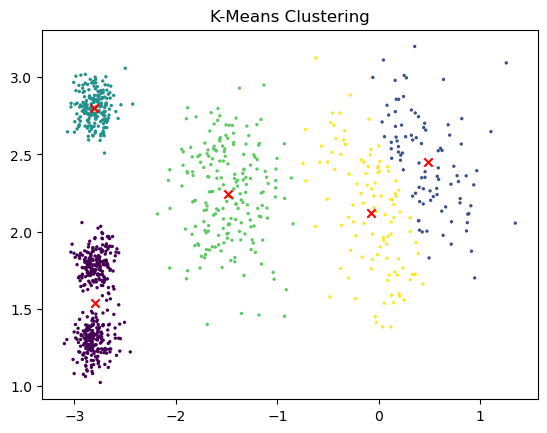

In [18]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=5)
model.fit(X)

labels = model.labels_
centroids = model.cluster_centers_

plt.scatter(X[:,0], X[:,1],c=labels, s=2)
plt.scatter(centroids[:,0], centroids[:,1], c='red', marker ='x')
plt.title("K-Means Clustering")
plt.show()


<div class="alert alert-warning" style="margin-top: 0px">
Your answer here : The algorithm detected 5 clusters in the data. However, it feels like the data are not separated well since as we can see on the graph, the gray cluster should contain 2 different clusters.
</div>

**Q2.** Playing with the argument `random_state` (i.e., changing the seed), and setting `n_init = 1`, display two different solutions retrieved by K-Means.

Then answer the following questions :
* Why can K-Means find two different solutions ?
* Which of the two solutions should we keep ?
* What is then recommended to do when using K-Means to prevent this problem ?

C:\Users\maner\anaconda3\envs\ml1\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\maner\anaconda3\envs\ml1\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


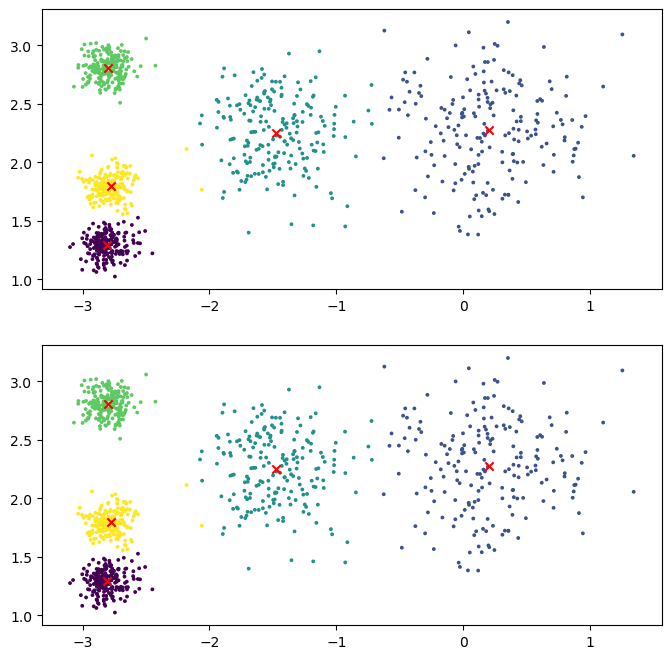

In [15]:
kmeans1 = KMeans(n_clusters=5, random_state=50, n_init=1)
kmeans1.fit(X)

labels1 = kmeans1.labels_
centroids1 = kmeans1.cluster_centers_

kmeans2 = KMeans(n_clusters=5, random_state=200, n_init=1)
kmeans2.fit(X)

labels2 = kmeans1.labels_
centroids2 = kmeans1.cluster_centers_


fig, axes = plt.subplots(2,1, figsize=(8,8))
axes[0].scatter(X[:,0], X[:,1],c=labels1, s=3)
axes[0].scatter(centroids1[:,0], centroids1[:,1], c='red', marker ='x')

axes[1].scatter(X[:,0], X[:,1],c=labels2, s=3)
axes[1].scatter(centroids2[:,0], centroids2[:,1], c='red', marker ='x')
plt.show()

<div class="alert alert-warning" style="margin-top: 0px">
Your answer here : The two solutions are different since we randomize the initial centroids. We should choose the solution with the lowest inertia because it fits better the data. To avoid getting different solutions, we should run KMeans several times by setting n_init > 1.
</div>

**Q3.** Display the plot corresponding to the elbow method (i.e., inertia vs. $K$). Which $K$ is optimal according to this method ? Comment.

C:\Users\maner\anaconda3\envs\ml1\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\maner\anaconda3\envs\ml1\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\maner\anaconda3\envs\ml1\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\maner\anaconda3\envs\ml1\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is k

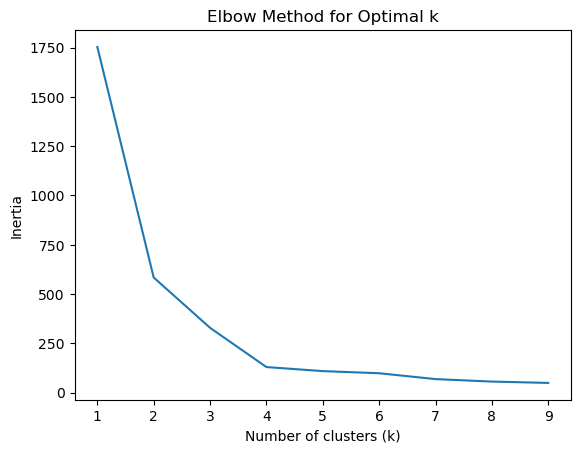

In [5]:
K = np.arange(1,10)
inertia_values = []

for k in K:
    kmeans_k = KMeans(n_clusters=k)
    kmeans_k.fit(X)
    inertia_values.append(kmeans_k.inertia_)

plt.plot(K, inertia_values)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

<div class="alert alert-warning" style="margin-top: 0px">
Your answer here : The best value of $K$ corresponding with the elbow method seems to be $K = 4$
</div>

**Q4.** Application : image segmentation.

Run the cell code below. Explain what the code is doing, and interpret the produced figure.

<div class="alert alert-warning" style="margin-top: 0px">
Your answer here : 
    
First of all, the code reshape the image of the ladybug into a 2D array so that KMeans can be applied on its pixels.

Then it loops over 3 different values of K = (2,4,8) representing the number of color clusters.

Inside the loop, we firstly fit the data with the K_clusters with the K wanted. After this, the color of each pixel is replaced by the color of its  corresponding cluster centroids to create a segmented image with K colors. We reshape the segmented_img with the shape of the initial shape of the picture which is a 3D array and is added to a list of segmented images.

To finish, the code displays the original picture and the 3 others pictures of the ladybug with reduced colors.
</div>

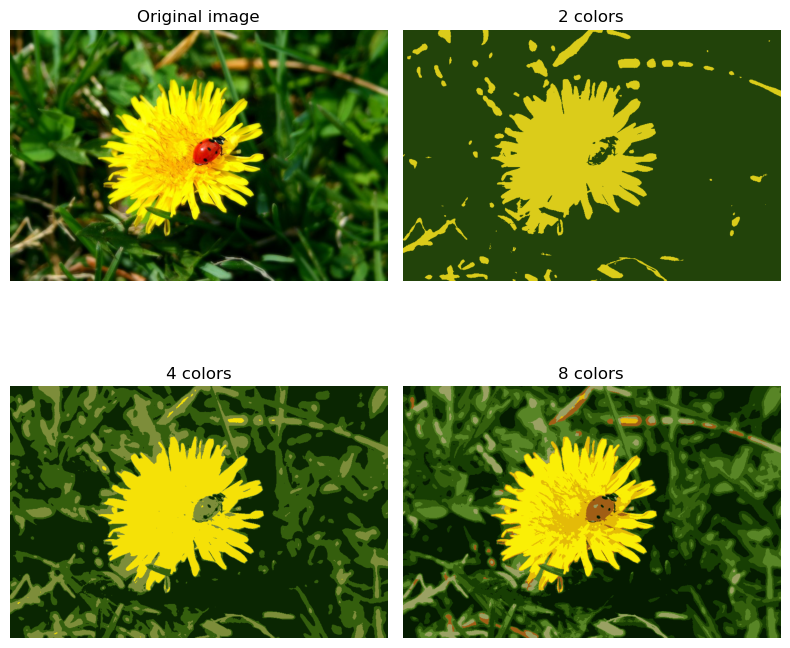

In [6]:
import PIL

image = np.asarray(PIL.Image.open('ladybug.png'))
X = image.reshape(-1, 3)

segmented_imgs = []

K_list = (2, 4, 8)
for K in K_list:
    kmeans = KMeans(n_clusters=K, n_init=10, random_state=0).fit(X)
    segmented_img = kmeans.cluster_centers_[kmeans.labels_]
    segmented_imgs.append(segmented_img.reshape(image.shape))

fig, ax = plt.subplots(2,2,figsize=(8,8))

ax[0,0].set_title("Original image")
ax[0,0].imshow(image)
ax[0,0].set_axis_off()

ax[0,1].set_title("2 colors")
ax[0,1].imshow(segmented_imgs[0]/255)
ax[0,1].set_axis_off()

ax[1,0].set_title("4 colors")
ax[1,0].imshow(segmented_imgs[1]/255)
ax[1,0].set_axis_off()

ax[1,1].set_title("8 colors")
ax[1,1].imshow(segmented_imgs[2]/255)
ax[1,1].set_axis_off()

plt.tight_layout()
plt.show()

### Exercise 2 - PCA

In this exercise, we are going to use the *Olivetti* dataset, which contains black-and-white pictures of faces.

In [7]:
from sklearn.datasets import fetch_olivetti_faces

X = fetch_olivetti_faces(shuffle=True, random_state=1).data
# Centering data, which is needed for PCA
X = X - np.mean(X, axis=0)

**Q1.** How many features do we have in this example ? Display a few images from the dataset.

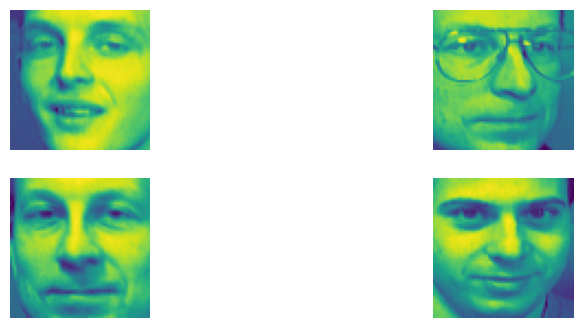

In [8]:
faces = fetch_olivetti_faces(shuffle=True, random_state=1).images

fig, ax = plt.subplots(2,2, figsize=(10, 4))
ax[0,0].imshow(faces[0])
ax[0,0].set_axis_off()

ax[0,1].imshow(faces[1])
ax[0,1].set_axis_off()

ax[1,0].imshow(faces[20])
ax[1,0].set_axis_off()

ax[1,1].imshow(faces[30])
ax[1,1].set_axis_off()

plt.show()

<div class="alert alert-warning" style="margin-top: 0px">
Your answer here : There are 4096 features corresponding to $64 \text{ x } 64$ pixels
</div>

**Q2.** Applying PCA to the dataset, how many components do we need to explain 95% of the variance ?

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95).fit(X)
n_components = pca.n_components_
print(f"We need {n_components} to explain 95% of the variance")

We need 123 to explain 95% of the variance


**Q3.** To reconstruct a point in its original representation, we can use the `inverse_transform` method.

Since we are working with images, after reducing the dimensionality, we will obtain an imperfect reconstruction of the original image.

Set now the number of components to 300. Select an image from the dataset, and compare it to its reconstruction.

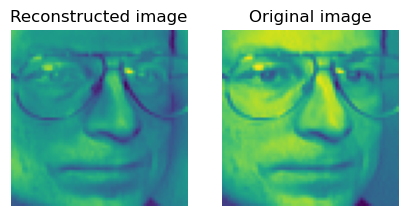

In [10]:
pca_300_nc = PCA(n_components=300)
X_reduced = pca_300_nc.fit_transform(X)

X_reconstruction = pca_300_nc.inverse_transform(X_reduced)

image_reconstructed = X_reconstruction[1].reshape(64,64)
fig, ax = plt.subplots(1,2, figsize=(5,5))

ax[0].imshow(image_reconstructed)
ax[0].axis("off")
ax[0].set_title("Reconstructed image")

ax[1].imshow(faces[1])
ax[1].axis("off")
ax[1].set_title("Original image")

plt.show()

<div class="alert alert-warning" style="margin-top: 0px">
Your answer here : The reconstructed image is darker and more blurred than the original. However, it's still recognizable.
</div>

**Q4.** For the same image, display in a subplot how the reconstruction evolves while keeping only 10, 20, 30... Up to 300 components.

What is the minimal number of components for which you consider the reconstruction to be acceptable ?

Conclude about the usefulness of this method.

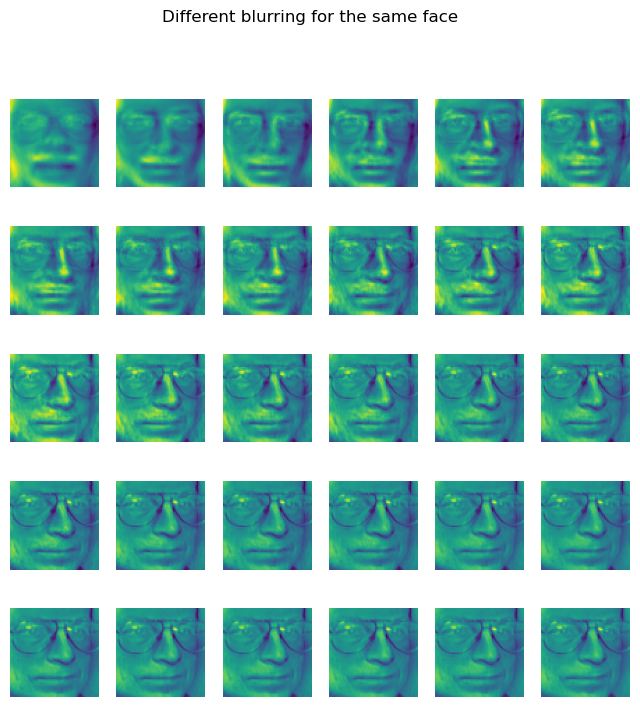

In [11]:
fig, axes = plt.subplots(5,6, figsize=(8,8))
components = 10
i_count = 0
j_count = 0
while components <= 300:
    model_pca = PCA(n_components=components)
    X_reduced = model_pca.fit_transform(X)
    X_reconstruction = model_pca.inverse_transform(X_reduced)
    image_reconstructed = X_reconstruction[1].reshape(64,64)
    axes[i_count, j_count].imshow(image_reconstructed)
    axes[i_count, j_count].axis("off")

    components += 10
    j_count = (j_count+1) % 6
    if j_count == 0:
        i_count += 1

plt.suptitle("Different blurring for the same face")
plt.show()
    

<div class="alert alert-warning" style="margin-top: 0px">
Your answer here : I consider that the minimum number of components is 150. When n_components is below 100, the picture is too much blurred to be acceptable and recognizable 
</div>

---

End of lab4.